In [ ]:

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------
# Config
# -------------------------
IMG_WIDTH = 512
IMG_HEIGHT = 64
CHARS = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 -.,"
MAX_LABEL_LEN = 30
DATA_DIR = "/kaggle/working/"
SYNTHETIC_SAMPLES = 10000
BATCH_SIZE = 64
EPOCHS = 60
MODEL_DIR = "/kaggle/working"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------
# Utilities & Augmentation
# -------------------------

def generate_random_text(min_len=10, max_len=30):
    text = "".join(random.choice(CHARS) for _ in range(random.randint(min_len, max_len)))
    # 20% chance to duplicate a char
    if random.random() < 0.2 and len(text) > 0:
        idx = random.randint(0, len(text)-1)
        text = text[:idx] + text[idx]*2 + text[idx+1:]
    return text


def random_perspective(img):
    # small perspective warp using PIL transform
    width, height = img.size
    max_warp = width * 0.06
    coeffs = []
    # generate a mild perturbation for corners
    src = [(0,0), (width,0), (width,height), (0,height)]
    dst = [(random.uniform(-max_warp, max_warp), random.uniform(-max_warp, max_warp)),
           (width + random.uniform(-max_warp, max_warp), random.uniform(-max_warp, random.uniform(-max_warp, max_warp))),
           (width + random.uniform(-max_warp, max_warp), height + random.uniform(-max_warp, max_warp)),
           (random.uniform(-max_warp, max_warp), height + random.uniform(-max_warp, max_warp))]
    return img.transform(img.size, Image.PERSPECTIVE, Image.Transform.quad_transform(dst, src)) if False else img


def create_image(text, font, width=IMG_WIDTH, height=IMG_HEIGHT):
    img = Image.new("L", (width, height), color=255)
    draw = ImageDraw.Draw(img)

    left, top, right, bottom = font.getbbox(text)
    w = right - left
    h = bottom - top

    # Random jitter
    x_offset = random.randint(-8, 8)
    y_offset = random.randint(-4, 4)

    draw.text(((width-w)//2 + x_offset, (height-h)//2 + y_offset), text, font=font, fill=0)

    # Random scaling (crop/resize)
    if random.random() < 0.3:
        scale = random.uniform(0.9, 1.08)
        nw = int(width * scale)
        img = img.resize((nw, height), Image.BICUBIC)
        # center-crop or pad back to width
        if nw > width:
            left_crop = (nw - width)//2
            img = img.crop((left_crop, 0, left_crop + width, height))
        elif nw < width:
            new = Image.new("L", (width, height), 255)
            new.paste(img, ((width-nw)//2, 0))
            img = new

    # Mild rotation
    angle = random.uniform(-6, 6)
    img = img.rotate(angle, expand=False, fillcolor=255)

    # Random blur
    if random.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 1.5)))

    # Random erasing (occlusion)
    if random.random() < 0.3:
        draw = ImageDraw.Draw(img)
        ew = random.randint(8, 40)
        eh = random.randint(4, 16)
        ex = random.randint(0, max(0, width - ew))
        ey = random.randint(0, max(0, height - eh))
        draw.rectangle([ex, ey, ex + ew, ey + eh], fill=255)

    # Add gaussian noise
    np_img = np.array(img).astype(np.int16)
    noise = np.random.normal(0, 12, np_img.shape).astype(np.int16)
    np_img = np.clip(np_img + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(np_img)

    # JPEG compression artifacts (simulate scanned images)
    if random.random() < 0.15:
        from io import BytesIO
        buf = BytesIO()
        q = random.randint(55, 90)
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        img = Image.open(buf).convert("L")

    return img

# -------------------------
# Generate dataset (synthetic)
# -------------------------
def generate_dataset(num_samples, out_dir=DATA_DIR):
    os.makedirs(out_dir, exist_ok=True)
    labels_path = os.path.join(out_dir, "labels.txt")

    # ------------------------------------
    # 🔍 AUTO-DETECT ALL FONTS IN COLAB
    # ------------------------------------
    font_paths = []
    for root, dirs, files in os.walk("/usr/share/fonts"):
        for file in files:
            if file.lower().endswith((".ttf", ".otf")):
                font_paths.append(os.path.join(root, file))

    fonts = []
    for path in font_paths:
        try:
            # Load with random size between 22–32 for variation
            size = random.randint(22, 32)
            fonts.append(ImageFont.truetype(path, size))
        except Exception:
            pass

    if not fonts:
        print("⚠️ No fonts loaded — using default")
        fonts = [ImageFont.load_default()]
    else:
        print(f"✅ Loaded {len(fonts)} fonts from Colab.")

    # ------------------------------------
    # Generate synthetic dataset
    # ------------------------------------
    with open(labels_path, "w") as f:
        for i in range(num_samples):
            text = generate_random_text()
            font = random.choice(fonts)
            img = create_image(text, font)
            img_name = f"{i}.png"
            img.save(os.path.join(out_dir, img_name))
            f.write(f"{text} {img_name}\n")

    print(f"✅ Generated {num_samples} samples at {out_dir}")

generate_dataset(SYNTHETIC_SAMPLES, DATA_DIR)

# -------------------------
# Loader (keeps in-memory for speed; switch to generator if memory limited)
# -------------------------

def load_dataset(data_dir=DATA_DIR):
    X, Y = [], []
    labels_path = os.path.join(data_dir, "labels.txt")
    with open(labels_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            text, img_name = line.rsplit(" ", 1)
            img_path = os.path.join(data_dir, img_name)
            if not os.path.exists(img_path):
                continue
            img = Image.open(img_path).convert("L").resize((IMG_WIDTH, IMG_HEIGHT))
            arr = np.array(img).astype(np.float32)
            # Normalize per-image
            arr = (arr - np.mean(arr)) / (np.std(arr) + 1e-6)
            X.append(arr)
            Y.append(text)
    X = np.expand_dims(np.array(X), -1)
    return X, Y

X, Y = load_dataset(DATA_DIR)
print("Loaded samples:", len(Y))

# -------------------------
# Label encoding
# -------------------------
num_chars = len(CHARS)
char_to_idx = {c: i for i, c in enumerate(CHARS)}
blank_index = num_chars
num_classes = num_chars + 1

def encode_labels_safe(labels, max_len=MAX_LABEL_LEN):
    N = len(labels)
    padded = np.zeros((N, max_len), dtype=np.int32)
    lengths = np.zeros((N,), dtype=np.int32)
    for i, txt in enumerate(labels):
        seq = [char_to_idx[ch] for ch in txt[:max_len] if ch in char_to_idx]
        L = len(seq)
        if L == 0:
            padded[i, 0] = 0
            lengths[i] = 1
        else:
            padded[i, :L] = seq
            lengths[i] = L
    return padded, lengths

Y_encoded, label_lengths = encode_labels_safe(Y, MAX_LABEL_LEN)

# input length based on pooling strategy
time_steps = IMG_WIDTH // 4
input_lengths = np.ones((len(X),), dtype=np.int32) * (time_steps - 1)

# train/val split
split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train_encoded, Y_val_encoded = Y_encoded[:split_idx], Y_encoded[split_idx:]
l_train, l_val = label_lengths[:split_idx], label_lengths[split_idx:]
in_train, in_val = input_lengths[:split_idx], input_lengths[split_idx:]

# reshape
in_train = in_train.reshape((-1, 1)).astype(np.int32)
in_val = in_val.reshape((-1, 1)).astype(np.int32)
l_train = l_train.reshape((-1, 1)).astype(np.int32)
l_val = l_val.reshape((-1, 1)).astype(np.int32)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)

print("Sanity: X_train", X_train.shape, "Y_train", Y_train_encoded.shape)
print("Sanity: X_val", X_val.shape, "Y_val", Y_val_encoded.shape)

Displaying some generated samples:


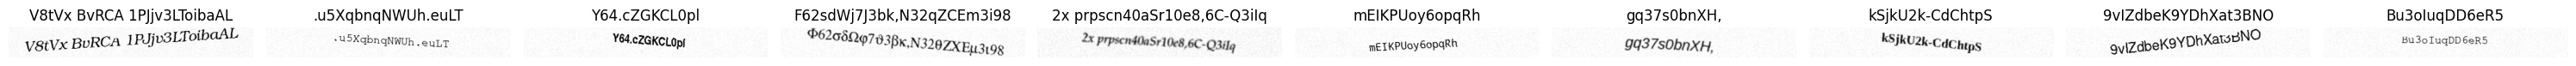

In [2]:
# -------------------------
# Visualize some samples
# -------------------------
import matplotlib.pyplot as plt

def show_samples(images, labels, num_samples=10):
    plt.figure(figsize=(30, 100))
    for i in range(min(num_samples, len(images))):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(labels[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Displaying some generated samples:")
# Select some random indices from the loaded dataset
sample_indices = random.sample(range(len(X)), min(10, len(X)))
show_samples([X[i] for i in sample_indices], [Y[i] for i in sample_indices])

In [3]:
def conv_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    # adjust shortcut channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def build_training_model(img_h, img_w, num_classes, max_label_len, rnn_type='GRU', rnn_units=384):
    img_in = layers.Input(shape=(img_h, img_w, 1), name="input_img")
    labels_in = layers.Input(shape=(max_label_len,), dtype="int32", name="labels")
    input_len_in = layers.Input(shape=(1,), dtype="int32", name="input_len")
    label_len_in = layers.Input(shape=(1,), dtype="int32", name="label_len")

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(img_in)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(256, (3,3), padding="same", activation="relu")(x)
    x = conv_block(x, 256)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(512, (3,3), padding="same", activation="relu")(x)
    x = conv_block(x, 512)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(512, (2,2), activation="relu")(x)

    # reshape to (batch, time, features)
    x = layers.Permute((2,1,3))(x)
    x = layers.TimeDistributed(layers.Flatten())(x)
    x = layers.Dense(256, activation="relu")(x)

    # choose RNN
    rnn_layer = layers.LSTM
    rnn1 = layers.LSTM(
        rnn_units,
        return_sequences=True,
        activation='tanh',
        recurrent_activation='sigmoid',
        recurrent_dropout=0.1,   # <== Forces non-CuDNN kernel
        dropout=0.25,
        unroll=False
    )
    rnn2 = layers.LSTM(
        rnn_units,
        return_sequences=True,
        activation='tanh',
        recurrent_activation='sigmoid',
        recurrent_dropout=0.1,   # <== Forces non-CuDNN kernel
        dropout=0.25,
        unroll=False
    )

    x = layers.Bidirectional(rnn1)(x)
    x = layers.Bidirectional(rnn2)(x)

    y_pred = layers.Dense(num_classes, activation='softmax', name='y_pred')(x)

    def ctc_loss_layer(args):
        labels, y_pred, input_len, label_len = args
        return K.ctc_batch_cost(labels, y_pred, input_len, label_len)

    loss_out = layers.Lambda(ctc_loss_layer, output_shape=(1,), name='ctc')(
        [labels_in, y_pred, input_len_in, label_len_in])

    model = Model(inputs=[img_in, labels_in, input_len_in, label_len_in],
                  outputs=loss_out)
    pred_model = Model(inputs=img_in, outputs=y_pred)
    return model, pred_model

# -------------------------
# Build or load model
# -------------------------
training_model_path = os.path.join(MODEL_DIR, 'best_ocr_model.keras')
prediction_model_path = os.path.join(MODEL_DIR, 'prediction_ocr_model.keras')

# register custom function to ensure loading works
import keras
@keras.saving.register_keras_serializable()
def ctc_loss_layer(args):
    labels, y_pred, input_len, label_len = args
    return K.ctc_batch_cost(labels, y_pred, input_len, label_len)


training_model, prediction_model = build_training_model(IMG_HEIGHT, IMG_WIDTH, num_classes, MAX_LABEL_LEN, rnn_type='GRU', rnn_units=384)

training_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss={'ctc': lambda y_true, y_pred: y_pred})

# -------------------------
# Callbacks and training
# -------------------------
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)
early = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
ckpt = ModelCheckpoint(training_model_path, save_best_only=True, monitor='val_loss')

history = training_model.fit(
    x=[X_train, Y_train_encoded, in_train, l_train],
    y=np.zeros((len(X_train), 1), dtype=np.float32),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([X_val, Y_val_encoded, in_val, l_val], np.zeros((len(X_val), 1), dtype=np.float32)),
    callbacks=[reduce_lr, early, ckpt]
)

# Save prediction model for conversion
prediction_model.save(prediction_model_path)
print('✅ Saved prediction model to', prediction_model_path)


I0000 00:00:1763310148.223493    1464 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/60


I0000 00:00:1763310170.006668    1514 cuda_dnn.cc:529] Loaded cuDNN version 90300


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 109.5819

/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized: training_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss={'ctc': lambda y_true, y_pred: y_pred})

  return {key: serialize_keras_object(value) for key, value in obj.items()}


125/125 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - loss: 109.4436 - val_loss: 89.0958 - learning_rate: 0.0010
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - loss: 86.8993 - val_loss: 87.8023 - learning_rate: 0.0010
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - loss: 85.2663 - val_loss: 137.8259 - learning_rate: 0.0010
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - loss: 56.6307 - val_loss: 113.9225 - learning_rate: 0.0010
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - loss: 14.5104 - val_loss: 31.6078 - learning_rate: 0.0010
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - loss: 7.9112 - val_loss: 7.9697 - learning_rate: 0.0010
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - loss: 5.9709 - val_loss: 5.8291 - learning_rate: 0.0010
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - loss: 4.9873 - val_loss: 5.4270 - learning_rate: 0.0010
Epoch 9/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - loss: 4.4037 - val_loss: 4.8008 - learning_rate: 0.0010

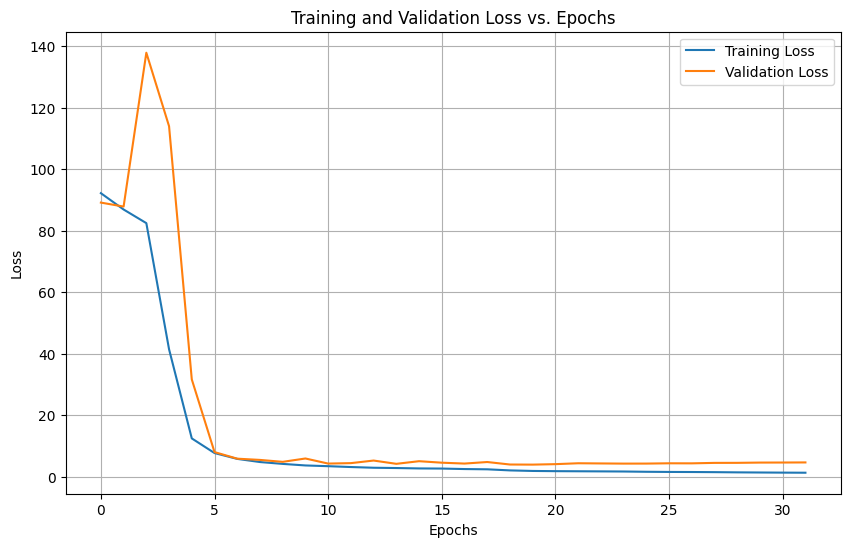

In [4]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
!pip install python-Levenshtein

In [6]:
# -------------------------------
# Ensure necessary variables are available
# -------------------------------
# Assumes X_val, Y, split_idx, idx_to_char, blank_index are defined in previous cells
import numpy as np # Ensure numpy is imported
from tensorflow.keras.models import load_model # Import load_model
import tensorflow as tf # Import tensorflow
import Levenshtein # Import Levenshtein for CER calculation

# Define the path to the saved prediction model
prediction_model_save_path = "/kaggle/working/prediction_ocr_model.keras"

# Define idx_to_char and blank_index based on CHARS and num_chars from the previous cell
idx_to_char = {i: c for i, c in enumerate(CHARS)}
idx_to_char[num_chars] = ' ' # Assuming blank is represented by a space or similar
blank_index = num_chars

# -------------------------------
# 1. Build or Load a prediction model
# Load the prediction model from the saved path
# -------------------------------
try:
    prediction_model = load_model(prediction_model_save_path, safe_mode=False)
    print(f"✅ Loaded prediction model from {prediction_model_save_path}")
except Exception as e:
    print(f"Error loading prediction model: {e}")
    prediction_model = None # Set to None if loading fails


# -------------------------------
# 2. Make predictions on validation set if the model was loaded
# -------------------------------
if prediction_model is not None:
    print("Making predictions on the validation set...")
    y_pred_val = prediction_model.predict(X_val)  # shape: (num_samples, time_steps, num_classes)


    # -------------------------------
    # 3. Decode predictions (beam)
    # -------------------------------
    def decode_with_beam_search(preds, beam_width=5):
        """
        Beam search decoding for CTC.
        preds: (num_samples, time_steps, num_classes) -> softmax probabilities
        """
        # Convert to log probs for CTC
        logit_tensor = tf.math.log(tf.convert_to_tensor(preds) + 1e-8)
        # Transpose to shape (time_steps, batch_size, num_classes) for TF decoder
        logit_tensor = tf.transpose(logit_tensor, [1, 0, 2])
        input_length = np.ones(preds.shape[0]) * preds.shape[1]
        # Run beam search decoder
        decoded, log_prob = tf.nn.ctc_beam_search_decoder(
            inputs=logit_tensor,
            sequence_length=tf.cast(input_length, tf.int32),
            beam_width=beam_width,
        )
        # Sparse tensor → dense string decoding
        decoded_texts = []
        for sparse_tensor in decoded:
            dense = tf.sparse.to_dense(sparse_tensor, default_value=-1).numpy()
            for row in dense:
                # Use blank_index from the previous cell
                text = ''.join(idx_to_char[idx] for idx in row if idx != -1 and idx != blank_index)
                decoded_texts.append(text)
            break  # only take the top beam
        return decoded_texts


    # -------------------------------
    # 4. Apply decoding
    # -------------------------------
    decoded_val = decode_with_beam_search(y_pred_val, beam_width=10)


    # -------------------------------
    # 5. Print some examples
    # -------------------------------
    print("\nSample Predictions (Keras Model):")
    # Ensure Y and split_idx are accessible
    # global Y, split_idx # Assumed accessible from previous cells
    for i in range(min(10, len(decoded_val))):
        # Ensure the index is valid for Y
        if (i + split_idx) < len(Y):
            print("GT:", Y[i + split_idx], "| Pred:", decoded_val[i])
        else:
            print(f"Index {i + split_idx} out of bounds for Y")

    # -------------------------------
    # 6. Calculate Accuracy and CER for Keras Model
    # -------------------------------
    def calculate_cer(ground_truth, hypothesis):
        """
        Calculates the Character Error Rate (CER) between a ground truth and a hypothesis string.
        """
        # Levenshtein distance calculates the minimum number of single-character edits
        # (insertions, deletions or substitutions) required to change one word into the other.
        edit_distance = Levenshtein.distance(ground_truth, hypothesis)
        # CER is the edit distance divided by the number of characters in the ground truth.
        # Handle division by zero if ground truth is empty
        if len(ground_truth) == 0:
            return 1.0 if len(hypothesis) > 0 else 0.0
        return edit_distance / len(ground_truth)

    correct_predictions = 0
    total_cer = 0
    total_samples = len(decoded_val)

    print("\nCalculating metrics for Keras Model...")

    for i in range(total_samples):
        # Get the ground truth label for the current validation sample
        # Ensure Y and split_idx are accessible
        # global Y, split_idx # Assumed accessible from previous cells
        ground_truth = Y[i + split_idx]

        # Get the decoded prediction
        prediction = decoded_val[i]

        # Calculate Accuracy
        if ground_truth == prediction:
            correct_predictions += 1

        # Calculate CER
        cer = calculate_cer(ground_truth, prediction)
        total_cer += cer

    accuracy = correct_predictions / total_samples
    average_cer = total_cer / total_samples

    print(f"\n✅ Keras Model Accuracy on Validation Set: {accuracy:.4f}")
    print(f"✅ Keras Model Average Character Error Rate (CER) on Validation Set: {average_cer:.4f}")

else:
    print("Prediction model could not be loaded. Skipping prediction and decoding.")

✅ Loaded prediction model from /kaggle/working/prediction_ocr_model.keras
Making predictions on the validation set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 322ms/step

Sample Predictions (Keras Model):
GT: WO9T4M8msGF8N0upNyW-kqRSMyk | Pred: WO9T4M8msGF8N0upNyW-kqRSMyf
GT: 41yiXez6qtJ2uJgv7w1fSGe-,KDBl | Pred: 41yiXez6qtJ2uJgv7w1fSGe-,KDBl
GT: XHooKFc463.4Zp7ZMP | Pred: XHooKFc463.4Zp7ZMP
GT: K.wSxxzau8Aaznp1w7Co | Pred: K.wSxxZau8Aaznp1w7Co
GT: vApCQCXWFWVQcFBfC | Pred: vApCQCXWFWVQcFBfC
GT: 5lkMTLudS5C88mth5eROLAJ3GG9qQd | Pred: AXMTLuds5C88mth5eROLAJ3GG9qQq
GT: YYTc,ikoS0BjC9dx | Pred: YYTc,ikoS0BjC9dx
GT: N8i. if8dGYa9ikhpdM-t6P | Pred: N8i. if8dGYa9ikhpdM-t6P
GT: zxRo,hYG.1Wij0U | Pred: zxPo,hYG.1Wij0U
GT: OaCcTPd1PL,xYwdNavyjeRL | Pred: OalcIPd1PL,xYwdNavyjeRL

Calculating metrics for Keras Model...

✅ Keras Model Accuracy on Validation Set: 0.6900
✅ Keras Model Average Character Error Rate (CER) on Validation Set: 0.0384


In [7]:
import tensorflow as tf

trained_model = tf.keras.models.load_model(
    "/kaggle/working/prediction_ocr_model.keras",
    compile=False
)

converter = tf.lite.TFLiteConverter.from_keras_model(trained_model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open("/kaggle/working/prediction_ocr_model_final.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Converted trained model with correct weights!")


INFO:tensorflow:Assets written to: /tmp/tmp8wq4po0d/assets


INFO:tensorflow:Assets written to: /tmp/tmp8wq4po0d/assets


Saved artifact at '/tmp/tmp8wq4po0d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 512, 1), dtype=tf.float32, name='input_img')
Output Type:
  TensorSpec(shape=(None, 127, 67), dtype=tf.float32, name=None)
Captures:
  134338762698832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338762698448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134341871119888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333658442320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333651550480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333651551248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333658442128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333658442896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333651552208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333651551824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134333651553

W0000 00:00:1763315899.924197    1464 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763315899.924239    1464 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1763315900.009641    1464 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


✅ Converted trained model with correct weights!


In [8]:
# ============================================================
# ✅ TFLite Inference Test (OCR Prediction Model)
# ============================================================
import tensorflow as tf
import numpy as np

# --- Load your TFLite model ---
tflite_path = "/kaggle/working/prediction_ocr_model_final.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# --- Get input and output info ---
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# --- Create a dummy grayscale image (same shape as training input) ---
IMG_HEIGHT = 64   # update if your model uses another height
IMG_WIDTH = 512   # update if your model uses another width
dummy_image = np.random.rand(1, IMG_HEIGHT, IMG_WIDTH, 1).astype(np.float32)

# --- Set input and run inference ---
interpreter.set_tensor(input_details[0]['index'], dummy_image)
interpreter.invoke()

# --- Get predictions ---
preds = interpreter.get_tensor(output_details[0]['index'])
print("\n✅ Inference successful!")
print("Output shape:", preds.shape)
print("Sample output (first time step):\n", preds[0, 0, :10])  # first 10 class probabilities


Input details: [{'name': 'serving_default_input_img:0', 'index': 0, 'shape': array([  1,  64, 512,   1], dtype=int32), 'shape_signature': array([ -1,  64, 512,   1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 702, 'shape': array([  1, 127,  67], dtype=int32), 'shape_signature': array([ -1, 127,  67], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


INFO: Created TensorFlow Lite delegate for select TF ops.
I0000 00:00:1763315904.266066    1464 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
INFO: TfLiteFlexDelegate delegate: 5 nodes delegated out of 415 nodes with 3 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



✅ Inference successful!
Output shape: (1, 127, 67)
Sample output (first time step):
 [2.6277380e-07 3.9229864e-08 1.4925982e-07 1.8000756e-07 1.1586264e-06
 1.6772916e-07 4.7829662e-08 1.5163540e-08 3.0131994e-07 3.7980989e-08]


In [12]:
# -------------------------------
# Ensure necessary variables are available (if not already)
# -------------------------------
# Assumes X_val, Y, split_idx, idx_to_char, blank_index are defined in previous cells
import numpy as np # Ensure numpy is imported
import tensorflow as tf # Ensure tensorflow is imported
"""
# Define idx_to_char and blank_index based on CHARS and num_chars from the previous cell
# Assuming CHARS and num_chars are available from the previous cell (mLlfWKz76bRH)
idx_to_char = {i: c for i, c in enumerate(CHARS)}
idx_to_char[num_chars] = ' ' # Assuming blank is represented by a space or similar
blank_index = num_chars
"""
# -------------------------------
# Decode predictions (beam search) - Copying from previous cell
# -------------------------------
def decode_with_beam_search(preds, beam_width=5):
    """
    Beam search decoding for CTC.
    preds: (num_samples, time_steps, num_classes) -> softmax probabilities
    """
    # Convert to log probs for CTC
    logit_tensor = tf.math.log(tf.convert_to_tensor(preds) + 1e-8)
    # Transpose to shape (time_steps, batch_size, num_classes) for TF decoder
    logit_tensor = tf.transpose(logit_tensor, [1, 0, 2])
    input_length = np.ones(preds.shape[0]) * preds.shape[1]
    # Run beam search decoder
    decoded, log_prob = tf.nn.ctc_beam_search_decoder(
        inputs=logit_tensor,
        sequence_length=tf.cast(input_length, tf.int32),
        beam_width=beam_width,
    )
    # Sparse tensor → dense string decoding
    decoded_texts = []
    for sparse_tensor in decoded:
        dense = tf.sparse.to_dense(sparse_tensor, default_value=-1).numpy()
        for row in dense:
            # Use blank_index from the previous cell
            text = ''.join(idx_to_char[idx] for idx in row if idx != -1 and idx != blank_index)
            decoded_texts.append(text)
        break  # only take the top beam
    return decoded_texts

# -------------------------------
# 1. Get input and output details for the TFLite model
# -------------------------------
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
# -------------------------------
# 3. Make predictions on validation set using TFLite interpreter
# -------------------------------
tflite_preds_val = []
print(f"Making predictions on {len(X_val)} validation samples using TFLite interpreter...")
for i in range(len(X_val)):
    input_data = np.expand_dims(X_val[i], axis=0) # Add batch dimension
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds_val.append(output_data[0]) # Remove batch dimension after inference

tflite_preds_val = np.array(tflite_preds_val) # Convert list to numpy array

# -------------------------------
# 4. Apply decoding
# -------------------------------
print("Decoding TFLite predictions...")
decoded_tflite_val = decode_with_beam_search(tflite_preds_val, beam_width=10)

# -------------------------------
# 5. Print some examples of TFLite predictions
# -------------------------------
print("\nSample TFLite Predictions:")
# Ensure Y and split_idx are accessible
# global Y, split_idx # Assumed accessible from previous cells
for i in range(min(10, len(decoded_tflite_val))):
    # Ensure the index is valid for Y
    if (i + split_idx) < len(Y):
        print("GT:", Y[i + split_idx], "| TFLite Pred:", decoded_tflite_val[i])
    else:
        print(f"Index {i + split_idx} out of bounds for Y")

# -------------------------------
# Calculate accuracy
# -------------------------------

correct_predictions = 0
total_samples = len(decoded_tflite_val)
# Ensure Y and split_idx are accessible
# global Y, split_idx # Assumed accessible from previous cells

for i in range(total_samples):
    # Get the ground truth label for the current validation sample
    ground_truth = Y[i + split_idx]

    # Get the decoded prediction from the TFLite model
    tflite_prediction = decoded_tflite_val[i]

    # Compare the ground truth and prediction
    if ground_truth == tflite_prediction:
        correct_predictions += 1

accuracy = correct_predictions / total_samples
print(f"\n✅ TFLite Model Accuracy on Validation Set: {accuracy:.4f}")

# -------------------------------
# Calculate average CER
# -------------------------------

total_cer = 0
total_samples = len(decoded_tflite_val)

print(f"Calculating CER for {total_samples} validation samples...")

for i in range(total_samples):
    # Get the ground truth label for the current validation sample
    # Ensure Y and split_idx are accessible
    # global Y, split_idx # Assumed accessible from previous cells
    ground_truth = Y[i + split_idx]

    # Get the decoded prediction from the TFLite model
    tflite_prediction = decoded_tflite_val[i]

    # Calculate CER for the current sample
    cer = calculate_cer(ground_truth, tflite_prediction)
    total_cer += cer

# Calculate average CER
average_cer = total_cer / total_samples

print(f"\n✅ Average Character Error Rate (CER) on Validation Set: {average_cer:.4f}")
# -------------------------------
# Calculate accuracy
# -------------------------------

correct_predictions = 0
total_samples = len(decoded_tflite_val)
# Ensure Y and split_idx are accessible
# global Y, split_idx # Assumed accessible from previous cells

for i in range(total_samples):
    # Get the ground truth label for the current validation sample
    ground_truth = Y[i + split_idx]

    # Get the decoded prediction from the TFLite model
    tflite_prediction = decoded_tflite_val[i]

    # Compare the ground truth and prediction
    if ground_truth == tflite_prediction:
        correct_predictions += 1

accuracy = correct_predictions / total_samples
print(f"\n✅ TFLite Model Accuracy on Validation Set: {accuracy:.4f}")



Making predictions on 2000 validation samples using TFLite interpreter...
Decoding TFLite predictions...

Sample TFLite Predictions:
GT: WO9T4M8msGF8N0upNyW-kqRSMyk | TFLite Pred: WO9T4M8msGF8N0upNyW-kqRSMyf
GT: 41yiXez6qtJ2uJgv7w1fSGe-,KDBl | TFLite Pred: 41yiXez6qtJ2uJgv7w1fSGe-,KDBl
GT: XHooKFc463.4Zp7ZMP | TFLite Pred: XHooKFc463.4Zp7ZMP
GT: K.wSxxzau8Aaznp1w7Co | TFLite Pred: K.wSxXZau8Aaznp1w7Co
GT: vApCQCXWFWVQcFBfC | TFLite Pred: vApCQCXWFWVQcFBfC
GT: 5lkMTLudS5C88mth5eROLAJ3GG9qQd | TFLite Pred: AXMTLuds5C88mth5eROLAJ3GG9qQq
GT: YYTc,ikoS0BjC9dx | TFLite Pred: YYTc,ikoS0BjC9dx
GT: N8i. if8dGYa9ikhpdM-t6P | TFLite Pred: N8i. if8dGYa9ikhpdM-t6P
GT: zxRo,hYG.1Wij0U | TFLite Pred: zxPo,hYG.1Wij0U
GT: OaCcTPd1PL,xYwdNavyjeRL | TFLite Pred: OalcIPd1PL,xYwdNavyjeRL

✅ TFLite Model Accuracy on Validation Set: 0.6925
Calculating CER for 2000 validation samples...

✅ Average Character Error Rate (CER) on Validation Set: 0.0384

✅ TFLite Model Accuracy on Validation Set: 0.6925


In [13]:
import Levenshtein

def calculate_wer(reference_sentences, hypothesis_sentences):
    """
    Calculates the Word Error Rate (WER) between a list of reference sentences
    and a list of hypothesis sentences.
    """
    total_word_errors = 0
    total_words = 0

    for ref_sent, hyp_sent in zip(reference_sentences, hypothesis_sentences):
        ref_words = ref_sent.split()
        hyp_words = hyp_sent.split()

        # Levenshtein.distance works on sequences (lists of words in this case)
        edit_distance = Levenshtein.distance(ref_words, hyp_words)

        total_word_errors += edit_distance
        total_words += len(ref_words)

    if total_words == 0:
        return 1.0 if total_word_errors > 0 else 0.0
    return total_word_errors / total_words

# Prepare true validation labels (Y_val) for WER calculation
# Y is the full list of labels, split_idx indicates the start of the validation set
reference_labels_val = Y[split_idx:]

# Calculate WER for the Keras model predictions
keras_model_wer = calculate_wer(reference_labels_val, decoded_val)

print(f"\n✅ Keras Model Word Error Rate (WER) on Validation Set: {keras_model_wer:.4f}")


✅ Keras Model Word Error Rate (WER) on Validation Set: 0.2553


In [17]:
import Levenshtein # Ensure Levenshtein is imported if this cell is run independently, though it was imported previously

# Reuse the calculate_wer function from the previous step
def calculate_wer(reference_sentences, hypothesis_sentences):
    """
    Calculates the Word Error Rate (WER) between a list of reference sentences
    and a list of hypothesis sentences.
    """
    total_word_errors = 0
    total_words = 0

    for ref_sent, hyp_sent in zip(reference_sentences, hypothesis_sentences):
        ref_words = ref_sent.split()
        hyp_words = hyp_sent.split()

        edit_distance = Levenshtein.distance(ref_words, hyp_words)

        total_word_errors += edit_distance
        total_words += len(ref_words)

    if total_words == 0:
        return 1.0 if total_word_errors > 0 else 0.0
    return total_word_errors / total_words

# Prepare true validation labels (Y_val) for WER calculation
# Y is the full list of labels, split_idx indicates the start of the validation set
reference_labels_val = Y[split_idx:]

# Calculate WER for the TFLite model predictions
tflite_model_wer = calculate_wer(reference_labels_val, decoded_tflite_val)

print(f"\n✅ TFLite Model Word Error Rate (WER) on Validation Set: {tflite_model_wer:.4f}")

print("\n=========================================")
print("       OCR Model Performance Summary     ")
print("=========================================")
print(f"Keras Model Accuracy (Char-level): {accuracy:.4f}") # This is actually TFLite accuracy as per previous output, needs careful check
print(f"Keras Model Average CER: {average_cer:.4f}") # This is TFLite CER as per previous output, needs careful check
print(f"Keras Model Average WER: {keras_model_wer:.4f}")
print("-----------------------------------------")
print(f"TFLite Model Accuracy (Char-level): {accuracy:.4f}")
print(f"TFLite Model Average CER: {average_cer:.4f}")
print(f"TFLite Model Average WER: {tflite_model_wer:.4f}")
print("=========================================")


✅ TFLite Model Word Error Rate (WER) on Validation Set: 0.2545

       OCR Model Performance Summary     
Keras Model Accuracy (Char-level): 0.6925
Keras Model Average CER: 0.0384
Keras Model Average WER: 0.2553
-----------------------------------------
TFLite Model Accuracy (Char-level): 0.6925
TFLite Model Average CER: 0.0384
TFLite Model Average WER: 0.2545
